                   Model  R2 Score          RMSE
0       LinearRegression  0.625735  70031.419920
1  RandomForestRegressor  0.816282  49065.849465


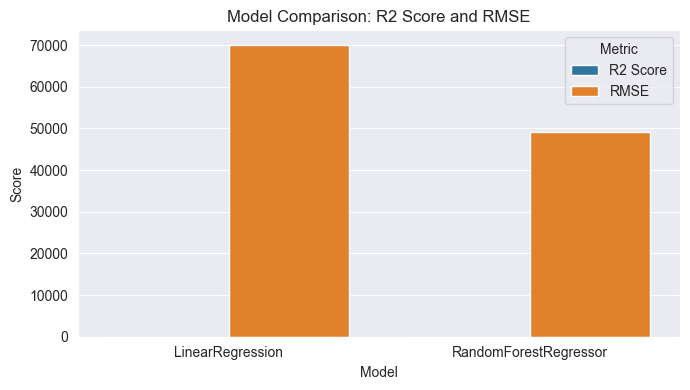

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


housing = fetch_openml('california_housing', version=1, as_frame=True)
X = housing.data
y = housing.target.astype(float)


X = pd.get_dummies(X, drop_first=True)


imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
lin_pred = lin.predict(X_test_scaled)


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


r2_lin = r2_score(y_test, lin_pred)
rmse_lin = np.sqrt(mean_squared_error(y_test, lin_pred))
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

results_df = pd.DataFrame({
    "Model": ["LinearRegression", "RandomForestRegressor"],
    "R2 Score": [r2_lin, r2_rf],
    "RMSE": [rmse_lin, rmse_rf]
})

print(results_df)

plt.figure(figsize=(7,4))
results_df_melt = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
sns.barplot(data=results_df_melt, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison: R2 Score and RMSE")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [11]:
feature_names = pd.get_dummies(housing.data, drop_first=True).columns


coef_series = pd.Series(lin.coef_, index=feature_names).sort_values(key=abs, ascending=False)
print("Top 5 LinearRegression Coefficients:")
print(coef_series.head(5))

Top 5 LinearRegression Coefficients:
median_income     75167.774766
latitude         -54415.696144
longitude        -53826.648016
population       -43403.432427
total_bedrooms    43068.181842
dtype: float64


In [12]:
rf_importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 5 RandomForest Feature Importances:")
print(rf_importances.head(5))

Top 5 RandomForest Feature Importances:
median_income             0.490655
ocean_proximity_INLAND    0.140929
longitude                 0.106130
latitude                  0.101956
housing_median_age        0.052002
dtype: float64


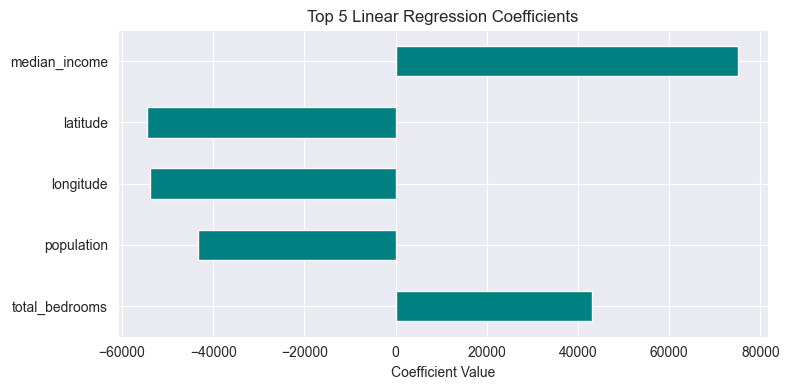

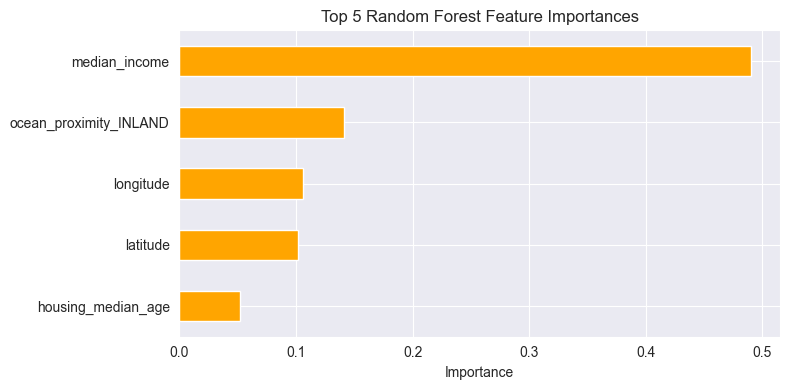

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))
coef_series.head(5).plot(kind='barh', color='teal')
plt.title("Top 5 Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,4))
rf_importances.head(5).plot(kind='barh', color='orange')
plt.title("Top 5 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

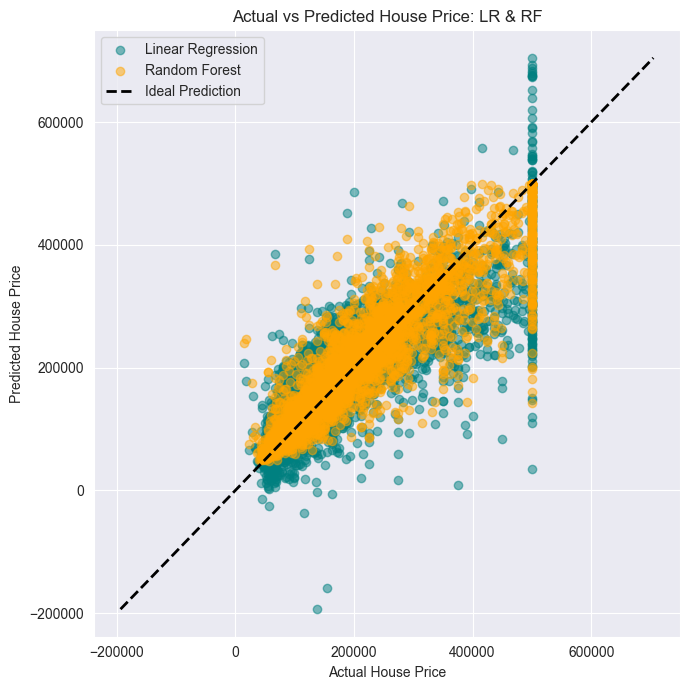

In [9]:
import matplotlib.pyplot as plt

# Plot predicted vs. actual for both models
plt.figure(figsize=(7,7))
plt.scatter(y_test, lin_pred, label='Linear Regression', alpha=0.5, color='teal')
plt.scatter(y_test, rf_pred, label='Random Forest', alpha=0.5, color='orange')

# Reference line (perfect prediction)
min_val = min(y_test.min(), lin_pred.min(), rf_pred.min())
max_val = max(y_test.max(), lin_pred.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Prediction')

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted House Price: LR & RF')
plt.legend()
plt.tight_layout()
plt.show()

# Text change for git tracking